In [1]:
import torch
print(torch.__version__, torch.cuda.is_available())

2.11.0+cu128 True


In [2]:
import librosa, numpy as np

path = librosa.ex('brahms')
y, sr = librosa.load(path, sr=44100, mono=True)

print("sample rate:", sr)
print("array shape:", y.shape)
print("duration:", len(y) / sr, "seconds")
print("first 10 values:", y[:10])

sample rate: 44100
array shape: (2021760,)
duration: 45.844897959183676 seconds
first 10 values: [-2.9855612e-05 -1.6038206e-05  2.9919415e-06  9.7568036e-06
  7.8457770e-06  8.9853729e-06  1.1919750e-05  8.9881996e-06
  4.0931532e-06  6.4900960e-06]


spectrogram shape: (128, 3949)


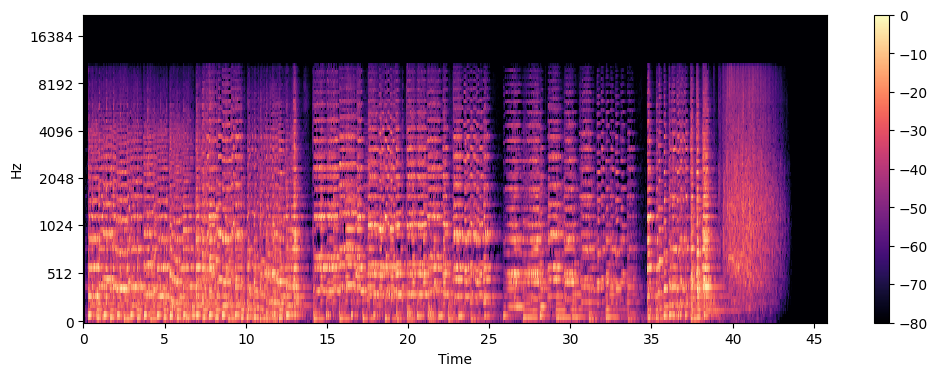

In [4]:
import matplotlib.pyplot as plt
import librosa.display

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
S_db = librosa.power_to_db(S, ref=np.max)

print("spectrogram shape:", S_db.shape)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar()
plt.show()

In [5]:
from transformers import ClapModel, ClapProcessor

model_id = "laion/larger_clap_music_and_speech"
model = ClapModel.from_pretrained(model_id).to("cuda").eval()
processor = ClapProcessor.from_pretrained(model_id)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

config.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  776MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/555 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  776MB            

...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

193.913882 M parameters


In [7]:
y48 = librosa.resample(y, orig_sr=44100, target_sr=48000)
clip = y48[:480000]
print(clip.shape)

(480000,)


In [12]:
import torch

inputs = processor(audio=clip, sampling_rate=48000, return_tensors="pt")
inputs = {k: v.to("cuda") for k, v in inputs.items()}

with torch.no_grad():
    audio_vec = model.get_audio_features(**inputs).pooler_output

audio_vec = audio_vec / audio_vec.norm(dim=-1, keepdim=True)
print(audio_vec.shape)
print(audio_vec[0][:8])

torch.Size([1, 512])
tensor([ 0.0737, -0.0923, -0.0516,  0.0101,  0.0654,  0.0675,  0.0208,  0.0042],
       device='cuda:0')


In [13]:
print(audio_vec.norm())

tensor(1., device='cuda:0')


In [14]:
texts = [
    "a solo violin playing a romantic classical melody",
    "aggressive heavy metal with distorted electric guitars",
    "upbeat funk with a slap bass groove",
    "ambient lo-fi hip hop for studying",
]

t_inputs = processor(text=texts, return_tensors="pt", padding=True)
t_inputs = {k: v.to("cuda") for k, v in t_inputs.items()}

with torch.no_grad():
    text_vecs = model.get_text_features(**t_inputs).pooler_output

text_vecs = text_vecs / text_vecs.norm(dim=-1, keepdim=True)
print(text_vecs.shape)

torch.Size([4, 512])


In [15]:
sims = (text_vecs @ audio_vec.T).squeeze()

for t, s in zip(texts, sims.tolist()):
    print(f"{s:+.4f}   {t}")

+0.3996   a solo violin playing a romantic classical melody
+0.0581   aggressive heavy metal with distorted electric guitars
+0.1009   upbeat funk with a slap bass groove
+0.0555   ambient lo-fi hip hop for studying
